Language Task NLP Part III.  
The sentiment classification of financial phrases with RNN, LSTM and Pre-trained Word Embeddings.

This notebook fulfills the language task / part III of text classification.  
Data set: financial phrase.csv that has two columns: text and label.

The workflow includes:

1. Dataset loading and pre-processing.  
2. Text cleaning and preprocessing.  
3. Distribution of classes and common words visualization.  
4. Padding the sequence with tokens and percentiles.  
5. Train / validation / test split.  
6. Model 1: Trainable simple RNN with embedding.  
7. Model 2: Trainable embedding LSTM.  
8. Model 3: LSTM with pre-trained GloVe/Word2Vec-like embeddings.  
9. Accuracy, confusion matrix and classification report.  
10. Analysis of errors with wrong predictions.  
11. Prediction GUI in real-time with Gradio.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:


!pip -q install contractions wordcloud gensim gradio nltk


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.6 MB/s eta 0:00:00


In [ ]:
# Import libraries


import os
import re
import time
import pickle
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
import contractions

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

warnings.filterwarnings("ignore")

# Download NLTK resources
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


TensorFlow version: 2.19.0
GPU available: True


In [ ]:


possible_paths = [
    "/content/drive/MyDrive/Data/FinancialPhraseDataset/financial_phrase.csv"
]

DATA_PATH = None
for path in possible_paths:
    if os.path.exists(path):
        DATA_PATH = path
        break

if DATA_PATH is None:
    try:
        from google.colab import files
        print("Please upload financial_phrase.csv")
        uploaded = files.upload()
        DATA_PATH = list(uploaded.keys())[0]
    except Exception as e:
        raise FileNotFoundError("financial_phrase.csv not found. Please upload the CSV file.") from e

df = pd.read_csv(DATA_PATH)

# Standardize column names
df.columns = [col.strip().lower() for col in df.columns]

# Check and rename columns if needed
if "text" not in df.columns or "label" not in df.columns:
    print("Current columns:", df.columns.tolist())
    raise ValueError("Dataset must contain 'text' and 'label' columns.")

print("Dataset loaded from:", DATA_PATH)
print("Dataset shape:", df.shape)
display(df.head())

Dataset loaded from: /content/drive/MyDrive/Data/FinancialPhraseDataset/financial_phrase.csv
Dataset shape: (2264, 2)


,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2264 entries, 0 to 2263
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2264 non-null   object
 1   label   2264 non-null   object
dtypes: object(2)
memory usage: 35.5+ KB
None

Missing values:
text     0
label    0
dtype: int64

Duplicate rows: 5

Class distribution:
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64

Text length statistics:


,text_length,word_count
count,2264.000000,2264.000000
mean,121.962456,22.441696
std,56.238979,10.147048
min,9.000000,2.000000
25%,79.000000,15.000000
50%,111.000000,21.000000
75%,157.000000,28.000000
max,315.000000,81.000000


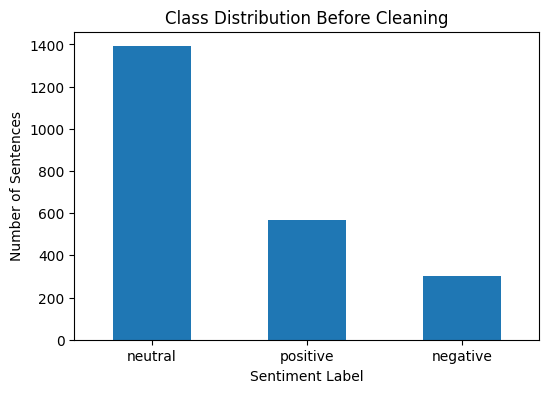

In [ ]:
# ============================================================
# 4. Dataset understanding
# ============================================================

print("Dataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nClass distribution:")
print(df["label"].value_counts())

# Basic text length analysis
df["text_length"] = df["text"].astype(str).apply(len)
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))

print("\nText length statistics:")
display(df[["text_length", "word_count"]].describe())

# Plot class distribution
plt.figure(figsize=(6, 4))
df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution Before Cleaning")
plt.xlabel("Sentiment Label")
plt.ylabel("Number of Sentences")
plt.xticks(rotation=0)
plt.show()

The data set consists of 2,264 text entries with sentiment labels, but without any missing values, and with 5 duplicate rows to be removed. A significant class distribution imbalance arises, with 1391 samples (61%) classified with a neutral sentiment, 570 samples (25%) classified with a positive sentiment and only 303 samples (13%) classified with a negative sentiment, which may require balancing techniques during model training. The analysis of text length shows that the length of the sentences is not uniform, ranging from a few words to many, with an average of 122 characters and 22 words (with standard deviations of 56 characters and 10 words, respectively), that warrants diverse text complexity to be taken into consideration in the pre-processing and feature engineering.

In [ ]:
# Text cleaning function


stop_words = set(stopwords.words("english"))

# Keep important sentiment/finance words because removing them can damage meaning.
important_words = {
    "not", "no", "nor",
    "up", "down", "increase", "decrease", "rise", "fall",
    "profit", "loss", "gain", "growth", "decline"
}
stop_words = stop_words - important_words

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove mentions and hashtag symbol
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", " ", text)

    # Remove numbers
    text = re.sub(r"\d+(\.\d+)?%?", " ", text)

    # Remove special characters and punctuation
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    tokens = []
    for word in text.split():
        if word not in stop_words and len(word) > 1:
            lemma = lemmatizer.lemmatize(word)
            tokens.append(lemma)

    return " ".join(tokens)

# Apply cleaning
df["clean_text"] = df["text"].apply(clean_text)

# Remove duplicate and empty cleaned text rows
before_rows = len(df)
df = df.drop_duplicates(subset=["text", "label"]).copy()
df = df[df["clean_text"].str.strip() != ""].copy()
after_rows = len(df)

print("Rows before cleaning:", before_rows)
print("Rows after removing duplicates/empty cleaned text:", after_rows)

display(df[["text", "clean_text", "label"]].head(10))

Rows before cleaning: 2264
Rows after removing duplicates/empty cleaned text: 2259


,text,clean_text,label
0,"According to Gran , the company has no plans t...",according gran company no plan move production...,neutral
1,"For the last quarter of 2010 , Componenta 's n...",last quarter componenta net sale doubled eur e...,positive
2,"In the third quarter of 2010 , net sales incre...",third quarter net sale increased eur mn operat...,positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,operating profit rose eur mn eur mn correspond...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",operating profit totalled eur mn up eur mn rep...,positive
5,Finnish Talentum reports its operating profit ...,finnish talentum report operating profit incre...,positive
6,Clothing retail chain Sepp+ñl+ñ 's sales incre...,clothing retail chain sepp sale increased eur ...,positive
7,Consolidated net sales increased 16 % to reach...,consolidated net sale increased reach eur oper...,positive
8,Foundries division reports its sales increased...,foundry division report sale increased eur mn ...,positive
9,"HELSINKI ( AFX ) - Shares closed higher , led ...",helsinki afx share closed higher led nokia ann...,positive


The cleaning function preprocesses the text data in several steps; it includes converting text to lowercase, expanding contractions, removing URLs, and removing mentions, hashtags, numbers, and special characters, and also keeps words that are important for the sentiment of the text, such as "not", "no", "up", "down", "profit", "loss", etc., that are usually removed as stopwords. Lemmatization and stopword removal reduced the dataset by 5 rows of duplicate entries and removing rows with cleaned text that was empty, leaving 2,264 entries to 2,259. In the sample output, you'll see that the original sentences, such as "Operating profit rose to EUR 13.1 mn from EUR 4.0 mn," have been replaced with the necessary tokens while preserving the critical components of the sentiment indicators, thereby preparing the data for more effective feature extraction and model training.

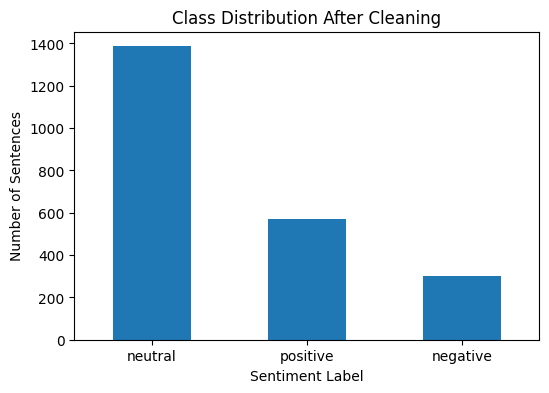

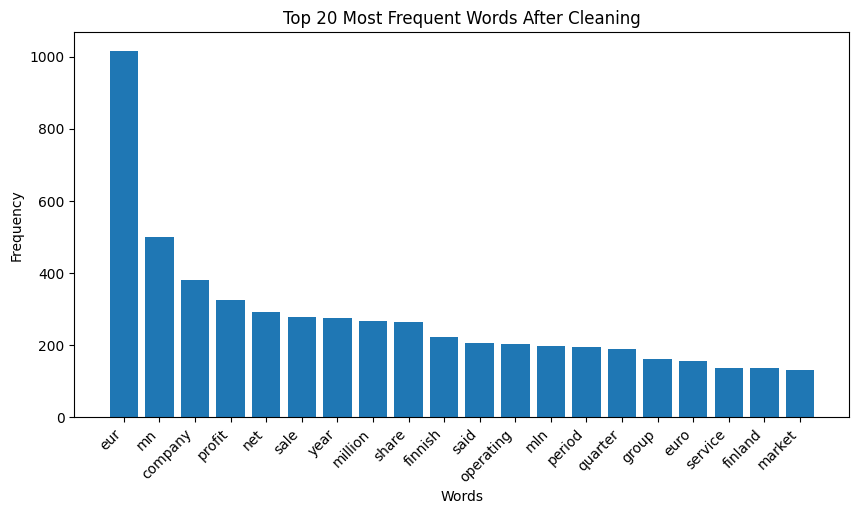

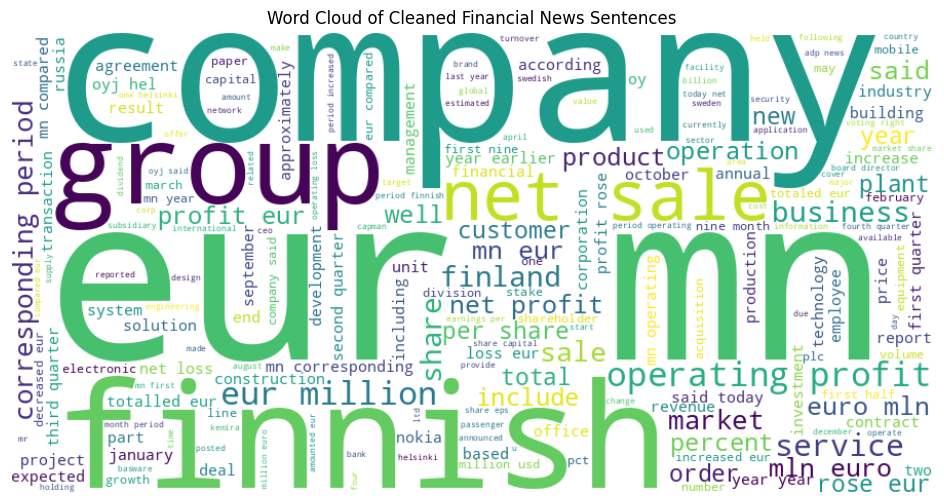

In [ ]:

# Visualize cleaned data


# Class distribution after cleaning
plt.figure(figsize=(6, 4))
df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution After Cleaning")
plt.xlabel("Sentiment Label")
plt.ylabel("Number of Sentences")
plt.xticks(rotation=0)
plt.show()

# Most frequent words
all_words = " ".join(df["clean_text"]).split()
word_freq = Counter(all_words)
common_words = word_freq.most_common(20)

words = [w for w, c in common_words]
counts = [c for w, c in common_words]

plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.title("Top 20 Most Frequent Words After Cleaning")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.show()

# Word cloud
try:
    from wordcloud import WordCloud

    wordcloud = WordCloud(width=900, height=450, background_color="white").generate(" ".join(all_words))

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Cleaned Financial News Sentences")
    plt.show()

except Exception as e:
    print("WordCloud could not be generated:", e)

In [ ]:

# Encode labels and split into train / validation / test

# Here, we use stratified 70% training, 15% validation and 15% testing.

label_encoder = LabelEncoder()
df["label_encoded"] = label_encoder.fit_transform(df["label"])

print("Label mapping:")
for idx, class_name in enumerate(label_encoder.classes_):
    print(idx, "->", class_name)

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label_encoded"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label_encoded"]
)

print("\nSplit sizes:")
print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Testing:", test_df.shape)

print("\nTraining label distribution:")
print(train_df["label"].value_counts())

print("\nValidation label distribution:")
print(val_df["label"].value_counts())

print("\nTesting label distribution:")
print(test_df["label"].value_counts())

Label mapping:
0 -> negative
1 -> neutral
2 -> positive

Split sizes:
Training: (1581, 6)
Validation: (339, 6)
Testing: (339, 6)

Training label distribution:
label
neutral     970
positive    399
negative    212
Name: count, dtype: int64

Validation label distribution:
label
neutral     208
positive     86
negative     45
Name: count, dtype: int64

Testing label distribution:
label
neutral     208
positive     85
negative     46
Name: count, dtype: int64


The sentiment labels were encoded numerically 0=negative, 1=neutral, 2=positive using LabelEncoder; then the dataset was split using stratified sampling so that the proportions of the classes were preserved in all the sets: 70% for training (1,581 samples), 15% for validation (339 samples), and 15% for testing (339 samples). The distribution of classes in the original data is maintained in each split, with nearly 61% of the samples in each split being from the neutral class, around 25% from the positive class and approximately 13% from the negative class in training, validation and test sets. This method stops data leakage, can optimise hyperparameters on the validation set, can give an unbiased test set evaluation of the model, but retains the real world class imbalance that the model will face in production.

In [ ]:

# Tokenization and percentile-based padding


MAX_WORDS = 10000
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(train_df["clean_text"])

X_train_seq = tokenizer.texts_to_sequences(train_df["clean_text"])
X_val_seq = tokenizer.texts_to_sequences(val_df["clean_text"])
X_test_seq = tokenizer.texts_to_sequences(test_df["clean_text"])

# Percentile-based max length avoids very long sentence outliers.
sequence_lengths = [len(seq) for seq in X_train_seq]
MAX_LEN = int(np.percentile(sequence_lengths, 95))
MAX_LEN = max(MAX_LEN, 5)

print("95th percentile sequence length:", MAX_LEN)
print("Maximum original sequence length:", max(sequence_lengths))
print("Average sequence length:", np.mean(sequence_lengths))

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

y_train = train_df["label_encoded"].values
y_val = val_df["label_encoded"].values
y_test = test_df["label_encoded"].values

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
num_classes = len(label_encoder.classes_)

print("Vocabulary size used:", vocab_size)
print("Number of classes:", num_classes)
print("Padded training shape:", X_train_pad.shape)
print("Padded validation shape:", X_val_pad.shape)
print("Padded testing shape:", X_test_pad.shape)

95th percentile sequence length: 22
Maximum original sequence length: 36
Average sequence length: 11.582542694497153
Vocabulary size used: 3958
Number of classes: 3
Padded training shape: (1581, 22)
Padded validation shape: (339, 22)
Padded testing shape: (339, 22)


Only 3,958 words are seen in the text data, but were tokenized with a vocabulary size of 10,000 words and an out-of-vocabulary token for words that are not in the vocabulary. A smart percentile-based approach was implemented using the 95th percentile (22 words) as the length of padding, which is sufficient to cover most sentences, without any outliers and with less computational cost, particularly with the average length of the sequence being around 12 words. Padded using post-padding and post-truncation to make the three datasets (training 1,581 samples, validation 339 samples, testing 339 samples), all of the same size of 22, and used for training the neural networks on the 3-class sentiment classification problem.


In [ ]:

#  Class weights for imbalance


class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {i: weight for i, weight in enumerate(class_weights_array)}

print("Class weights:")
for class_id, weight in class_weights.items():
    print(label_encoder.classes_[class_id], ":", round(weight, 3))

Class weights:
negative : 2.486
neutral : 0.543
positive : 1.321


To deal with the imbalance in the data, each class was weighted, with negative having a high weight (2.486), positive a moderate weight (1.321), and neutral the lowest (0.543) due to it having a large number of samples (970). This will not allow the model to be skewed toward the dominant class, and this will aid in learning in every sentiment class throughout training.

In [ ]:
#  Helper functions for training, plotting and evaluation


def get_callbacks(model_name):
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f"{model_name}.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]

def plot_history(history, model_name):
    # Accuracy
    plt.figure(figsize=(7, 4))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} - Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    # Loss
    plt.figure(figsize=(7, 4))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} - Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

def plot_confusion_matrix(cm, class_names, title):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
    plt.yticks(np.arange(len(class_names)), class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.show()

def evaluate_model(model, X_test, y_test, model_name, training_time):
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    y_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    print(f"\n{model_name} Test Accuracy: {test_accuracy:.4f}")
    print(f"{model_name} Test Loss: {test_loss:.4f}")
    print(f"{model_name} Training Time: {training_time:.2f} seconds")

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    ))

    cm = confusion_matrix(y_test, y_pred)
    plot_confusion_matrix(cm, label_encoder.classes_, f"{model_name} Confusion Matrix")

    return {
        "model": model_name,
        "test_accuracy": test_accuracy,
        "test_loss": test_loss,
        "training_time_seconds": training_time,
        "predictions": y_pred,
        "probabilities": y_prob
    }

## Model 1: Simple RNN with Trainable Embedding Layer


The model is trained on the data itself and learns word embeddings, then applies a Simple RNN layer to the sequence of words.  
It is employed as the initial baseline model to compare it.

In [ ]:

#  Model 1: Simple RNN with trainable embedding


def build_simple_rnn_model():
    model = Sequential([
        Input(shape=(MAX_LEN,)),
        Embedding(input_dim=vocab_size, output_dim=128),
        SimpleRNN(64),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

rnn_model = build_simple_rnn_model()
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 22, 128)        │       506,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 523,331 (2.00 MB)

 Trainable params: 523,331 (2.00 MB)

 Non-trainable params: 0 (0.00 B)

This Simple RNN model architecture includes an embedding layer that maps word indices to 128-dimensional vectors (506,624 parameters), a SimpleRNN layer with 64 units to learn sequential patterns, two dropout layers with a 0.3 rate for regularization, a dense hidden layer with 64 neurons and ReLU activation and a final softmax output layer for 3-class sentiment classification. The model is trained with 523331 trainable parameters (2 MB), optimizes with the Adam optimizer with the sparse categorical crossentropy loss, and regularizes for overfitting with dropout.


Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3477 - loss: 1.0956
Epoch 1: val_loss improved from None to 0.70162, saving model to best_simple_rnn_model.keras

Epoch 1: finished saving model to best_simple_rnn_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - accuracy: 0.4516 - loss: 1.0427 - val_accuracy: 0.7522 - val_loss: 0.7016 - learning_rate: 0.0010
Epoch 2/15
44/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7727 - loss: 0.7249
Epoch 2: val_loss improved from 0.70162 to 0.70018, saving model to best_simple_rnn_model.keras

Epoch 2: finished saving model to best_simple_rnn_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8065 - loss: 0.6344 - val_accuracy: 0.7375 - val_loss: 0.7002 - learning_rate: 0.0010
Epoch 3/15
45/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8919 - loss: 0.4211
Epoch 3: val_loss improved from 0.70018 to 0.58455, saving model to best_simple_rnn_model.keras

Epoch 3: finished saving model to best_simple_rnn_model

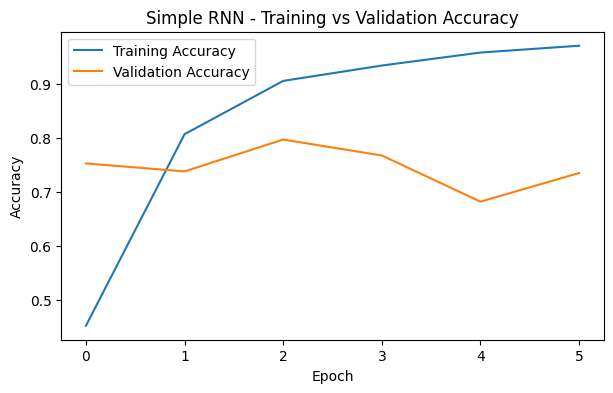

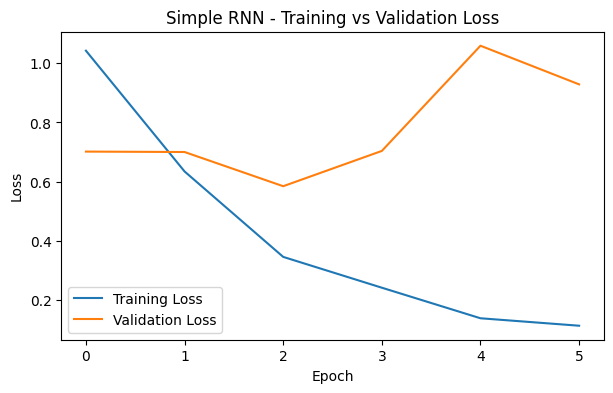


Simple RNN Test Accuracy: 0.8024
Simple RNN Test Loss: 0.6339
Simple RNN Training Time: 11.49 seconds

Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.50      0.60        46
     neutral       0.86      0.88      0.87       208
    positive       0.68      0.76      0.72        85

    accuracy                           0.80       339
   macro avg       0.76      0.72      0.73       339
weighted avg       0.80      0.80      0.80       339



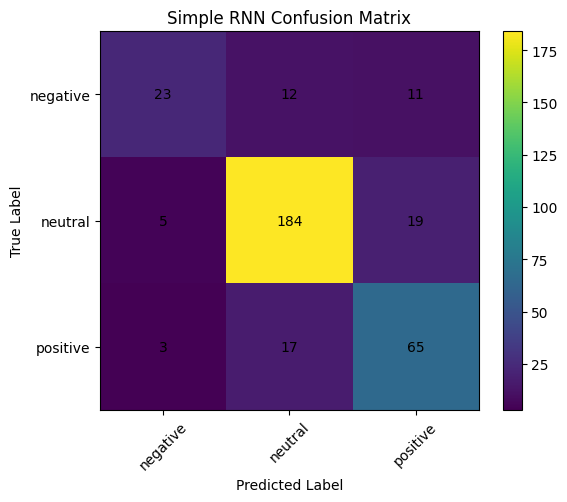

In [ ]:
# Train Simple RNN model

start_time = time.time()

history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=get_callbacks("best_simple_rnn_model"),
    verbose=1
)

rnn_training_time = time.time() - start_time

plot_history(history_rnn, "Simple RNN")
rnn_results = evaluate_model(
    rnn_model,
    X_test_pad,
    y_test,
    "Simple RNN",
    rnn_training_time
)

The Simple RNN model was trained for 6 epochs (stopped after 15) in 11.49 seconds and attained 80.24% test accuracy with the validation loss decreasing from 0.70 to 0.58 at epoch 3 but increasing thereafter due to overfitting. It has the best accuracy on the majority neutral class (86% precision, 88% recall, F1: 0.87) followed by moderate accuracy on positive sentiment class (68% precision, 76% recall, F1: 0.72), and the lowest on the minority negative class (74% precision, 50% recall, F1: 0.60), which shows that the class imbalance still affects the model's performance, despite class weights. The training accuracy was 97% at epoch 6 and reduced again to 0.0005 after that; this avoided overfitting further and ensured that training accuracy was not affected.


##Model 2: Trainable Embedding Layer LSTM.

The LSTM is a better choice in the long dependency aspects as compared to the Simple RNN.  
It employs memory gates to minimize the vanishing gradient problem and recollect significant details in the sentence.

In [ ]:

#  Model 2: LSTM with trainable embedding


def build_lstm_model():
    model = Sequential([
        Input(shape=(MAX_LEN,)),
        Embedding(input_dim=vocab_size, output_dim=128),
        LSTM(64),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

lstm_model = build_lstm_model()
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 22, 128)        │       506,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 560,387 (2.14 MB)

 Trainable params: 560,387 (2.14 MB)

 Non-trainable params: 0 (0.00 B)

The LSTM model is essentially the same as the Simple RNN model, but with the SimpleRNN layer replaced by LSTM layer (64 units, 49,408 parameters), which is able to model the long-term dependencies with its gating mechanisms. The model includes 560,387 trainable parameters (2.14 MB), which is approximately 37,000 more parameters than the Simple RNN because of the more complex model cell structure in LSTM, input gates, forget gates, and output gates, and the same embedding layer (128-dimensional), dropout regularization (0.3), dense hidden layer (64 neurons), and softmax output for 3-class sentiment classification.

Epoch 1/15
44/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3328 - loss: 1.1098
Epoch 1: val_loss improved from None to 1.05386, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4415 - loss: 1.0974 - val_accuracy: 0.6726 - val_loss: 1.0539 - learning_rate: 0.0010
Epoch 2/15
47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6875 - loss: 0.9277
Epoch 2: val_loss improved from 1.05386 to 0.83195, saving model to best_lstm_model.keras

Epoch 2: finished saving model to best_lstm_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6856 - loss: 0.8498 - val_accuracy: 0.6726 - val_loss: 0.8319 - learning_rate: 0.0010
Epoch 3/15
43/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7604 - loss: 0.6521
Epoch 3: val_loss improved from 0.83195 to 0.65951, saving model to best_lstm_model.keras

Epoch 3: finished saving model to best_lstm_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 

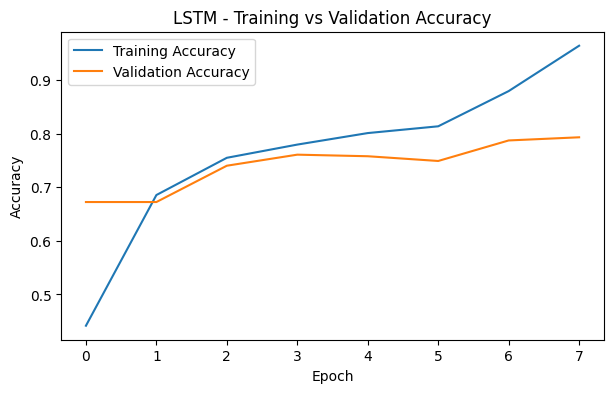

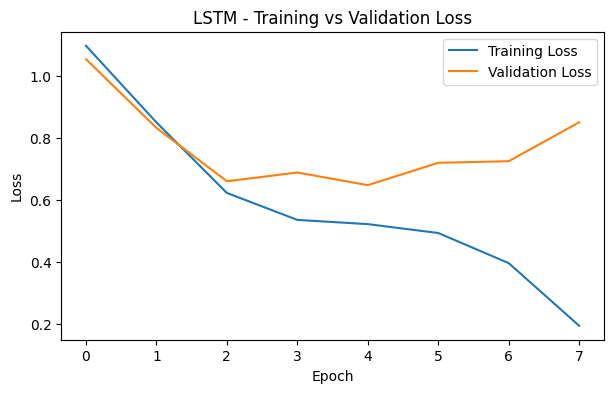


LSTM Test Accuracy: 0.7198
LSTM Test Loss: 0.7793
LSTM Training Time: 10.83 seconds

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        46
     neutral       0.94      0.81      0.87       208
    positive       0.47      0.89      0.62        85

    accuracy                           0.72       339
   macro avg       0.47      0.57      0.50       339
weighted avg       0.69      0.72      0.69       339



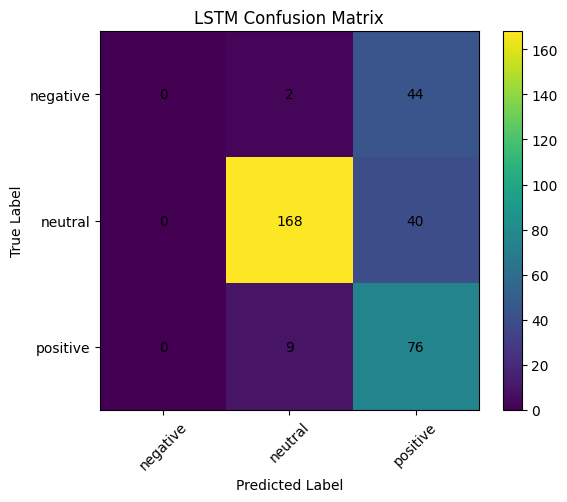

In [ ]:
# Train LSTM model

start_time = time.time()

history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=get_callbacks("best_lstm_model"),
    verbose=1
)

lstm_training_time = time.time() - start_time

plot_history(history_lstm, "LSTM")
lstm_results = evaluate_model(
    lstm_model,
    X_test_pad,
    y_test,
    "LSTM",
    lstm_training_time
)

## Model 3: LSTM with Pre-trained Word Embeddings


This model consists of LSTM with pre-trained word embeddings.

The direction requests to use Word2Vec embeddings, which have been pre-trained.  
The same notebook utilizes the same approach as the sample appendix, which utilizes gensim.downloader and glove-wiki-gigaword-50.  
The word vectors are trained and stored as GloVe vectors, which are then fed into an LSTM model.

In [ ]:
!pip install -q "numpy<2.0" gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 88.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is inc

In [ ]:
embedding_dim = 50

In [ ]:
# ============================================================
# 13. Load pre-trained word embeddings using Gensim
# ============================================================
# This step needs internet access. It will work in Google Colab.
# If gensim gives a compatibility error, run:
# !pip install -q "numpy<2.0" gensim
# Then restart runtime and run the notebook again.

import gensim.downloader as api

embedding_dim = 50

print("Downloading/loading pre-trained embeddings...")
pretrained_embedding = api.load("glove-wiki-gigaword-50")
print("Embedding model loaded.")

Downloading/loading pre-trained embeddings...
[==================================================] 100.0% 66.0/66.0MB downloaded
Embedding model loaded.


In [ ]:
embedding_dim = 50

In [ ]:

#  Build embedding matrix


word_index = tokenizer.word_index
embedding_matrix = np.zeros((vocab_size, embedding_dim))

covered_words = 0

for word, i in word_index.items():
    if i >= vocab_size:
        continue

    if word in pretrained_embedding:
        embedding_matrix[i] = pretrained_embedding[word]
        covered_words += 1

coverage = covered_words / (vocab_size - 1)

print("Covered words:", covered_words)
print("Vocabulary size:", vocab_size)
print("Embedding coverage:", round(coverage * 100, 2), "%")
print("Embedding matrix shape:", embedding_matrix.shape)

Covered words: 3596
Vocabulary size: 3958
Embedding coverage: 90.88 %
Embedding matrix shape: (3958, 50)


Using a pre-trained embedding matrix, the pre-trained word vectors of words in the tokenizer's vocabulary were mapped to their corresponding 50-dimensional vectors to create a pre-trained embedding matrix of shape (3958, 50), which resulted in a coverage rate of 90.88% (3596 out of 3958 words matched). Words not appearing in the pre-trained embeddings are assigned to zero vectors, and will either stay as zero vectors (if the embedding layer is not trained) or be learned during training (if the embedding layer is not trained), and then be used to benefit from the semantic knowledge gained from the pre-trained embeddings during initial training.

In [ ]:

#  Model 3: LSTM with pre-trained embeddings

def build_lstm_pretrained_model():
    model = Sequential([
        Input(shape=(MAX_LEN,)),
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            trainable=False
        ),
        LSTM(64),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

lstm_pretrained_model = build_lstm_pretrained_model()
lstm_pretrained_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 22, 50)         │       197,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 231,695 (905.06 KB)

 Trainable params: 33,795 (132.01 KB)

 Non-trainable params: 197,900 (773.05 KB)

Epoch 1/15
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3908 - loss: 1.0462
Epoch 1: val_loss improved from None to 0.68332, saving model to best_lstm_pretrained_model.keras

Epoch 1: finished saving model to best_lstm_pretrained_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5161 - loss: 0.9815 - val_accuracy: 0.7345 - val_loss: 0.6833 - learning_rate: 0.0010
Epoch 2/15
48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6938 - loss: 0.8070
Epoch 2: val_loss improved from 0.68332 to 0.57091, saving model to best_lstm_pretrained_model.keras

Epoch 2: finished saving model to best_lstm_pretrained_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6667 - loss: 0.8067 - val_accuracy: 0.7050 - val_loss: 0.5709 - learning_rate: 0.0010
Epoch 3/15
48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7268 - loss: 0.7251
Epoch 3: val_loss improved from 0.57091 to 0.56329, saving model to best_lstm_pretrained_model.keras

Epoch 3: finished saving mod

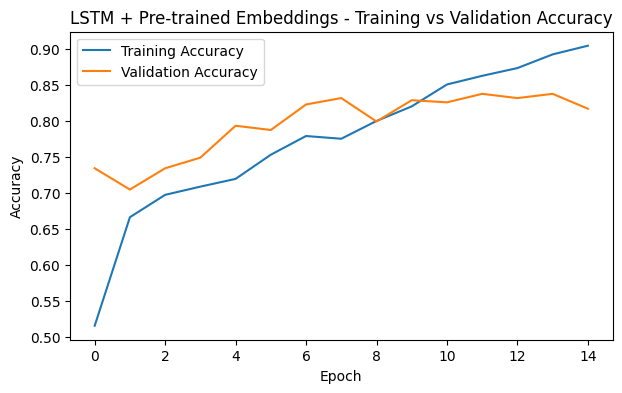

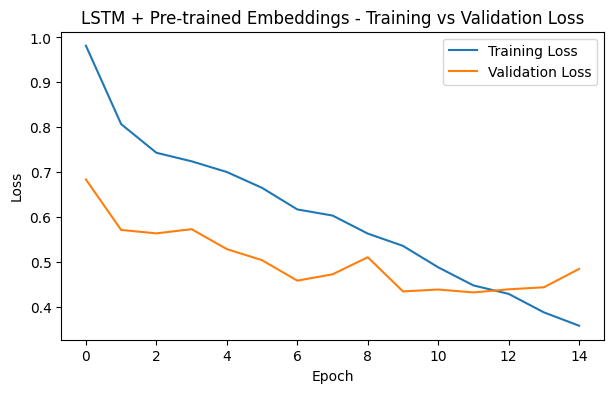


LSTM + Pre-trained Embeddings Test Accuracy: 0.8112
LSTM + Pre-trained Embeddings Test Loss: 0.4974
LSTM + Pre-trained Embeddings Training Time: 21.17 seconds

Classification Report:
              precision    recall  f1-score   support

    negative       0.63      0.52      0.57        46
     neutral       0.93      0.88      0.91       208
    positive       0.64      0.79      0.71        85

    accuracy                           0.81       339
   macro avg       0.74      0.73      0.73       339
weighted avg       0.82      0.81      0.81       339



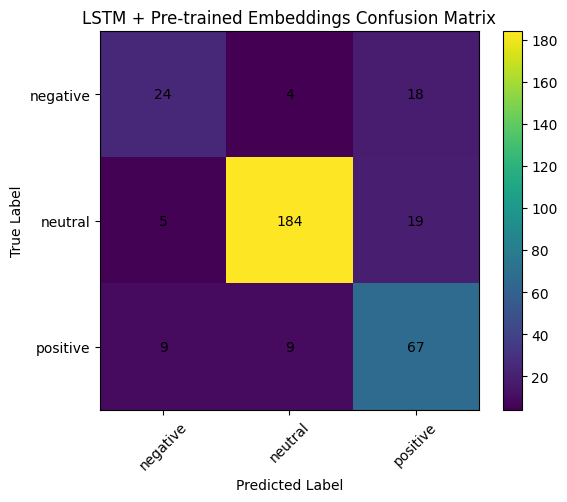

In [ ]:
# Train LSTM + pre-trained embedding model

start_time = time.time()

history_lstm_pretrained = lstm_pretrained_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=get_callbacks("best_lstm_pretrained_model"),
    verbose=1
)

lstm_pretrained_training_time = time.time() - start_time

plot_history(history_lstm_pretrained, "LSTM + Pre-trained Embeddings")
lstm_pretrained_results = evaluate_model(
    lstm_pretrained_model,
    X_test_pad,
    y_test,
    "LSTM + Pre-trained Embeddings",
    lstm_pretrained_training_time
)

,Model,Test Accuracy,Test Loss,Training Time (seconds)
0,Simple RNN,0.802360,0.633876,11.487539
1,LSTM,0.719764,0.779256,10.834923
2,LSTM + Pre-trained Embeddings,0.811209,0.497355,21.170732


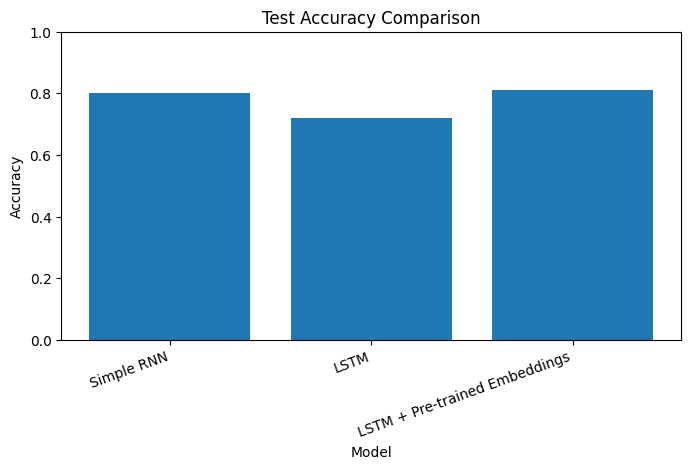

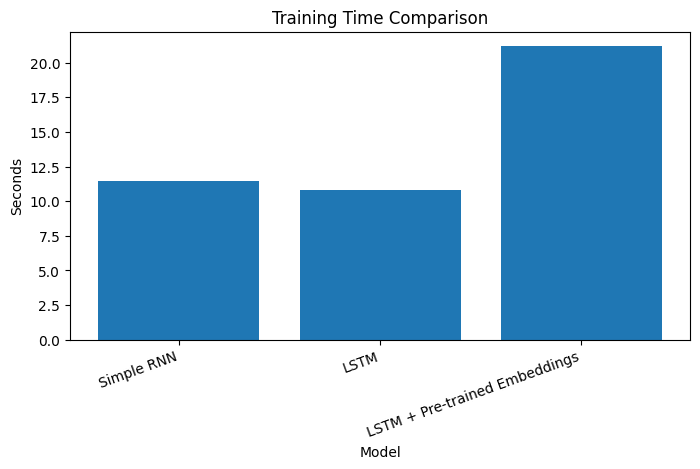

In [ ]:

#  Compare Model 1 vs Model 2 vs Model 3


results_df = pd.DataFrame([
    {
        "Model": rnn_results["model"],
        "Test Accuracy": rnn_results["test_accuracy"],
        "Test Loss": rnn_results["test_loss"],
        "Training Time (seconds)": rnn_results["training_time_seconds"]
    },
    {
        "Model": lstm_results["model"],
        "Test Accuracy": lstm_results["test_accuracy"],
        "Test Loss": lstm_results["test_loss"],
        "Training Time (seconds)": lstm_results["training_time_seconds"]
    },
    {
        "Model": lstm_pretrained_results["model"],
        "Test Accuracy": lstm_pretrained_results["test_accuracy"],
        "Test Loss": lstm_pretrained_results["test_loss"],
        "Training Time (seconds)": lstm_pretrained_results["training_time_seconds"]
    }
])

display(results_df)

# Accuracy comparison
plt.figure(figsize=(8, 4))
plt.bar(results_df["Model"], results_df["Test Accuracy"])
plt.title("Test Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.show()

# Training time comparison
plt.figure(figsize=(8, 4))
plt.bar(results_df["Model"], results_df["Training Time (seconds)"])
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Seconds")
plt.xticks(rotation=20, ha="right")
plt.show()

We see that LSTM with pre-trained embeddings beats Simple RNN and standard LSTM in this example with 81.12% test accuracy and lowest loss (0.497), highlighting the superior semantic understanding that can be gained by using pre-trained embeddings for sentiment classification. Interestingly, the standard LSTM is the poorest performing with its highly complicated design, possibly because either it overfits or has training instability, whereas simple RNN is surprisingly competitive with the fastest training time, 11.49 seconds, compared to standard LSTM (10.83 seconds) and pre-trained LSTM (21.17 seconds, which is almost double because of the larger embedding dimensions and added complexity). The results show that pre-trained embeddings offer the best improvement with a relatively small increase in training time, as the higher accuracy and generalization are valuable.

In [ ]:

#  Error analysis


# Select the best model based on test accuracy
all_results = {
    "Simple RNN": (rnn_model, rnn_results),
    "LSTM": (lstm_model, lstm_results),
    "LSTM + Pre-trained Embeddings": (lstm_pretrained_model, lstm_pretrained_results)
}

best_model_name = results_df.sort_values("Test Accuracy", ascending=False).iloc[0]["Model"]
best_model, best_results = all_results[best_model_name]

print("Best model:", best_model_name)

y_pred_best = best_results["predictions"]

error_df = test_df.copy()
error_df["actual_label"] = label_encoder.inverse_transform(y_test)
error_df["predicted_label"] = label_encoder.inverse_transform(y_pred_best)

misclassified = error_df[error_df["actual_label"] != error_df["predicted_label"]]

print("Total misclassified examples:", len(misclassified))
display(misclassified[["text", "clean_text", "actual_label", "predicted_label"]].head(5))

print("\n2-3 misclassified examples for report:")
display(misclassified[["text", "actual_label", "predicted_label"]].head(3))

Best model: LSTM + Pre-trained Embeddings
Total misclassified examples: 64


,text,clean_text,actual_label,predicted_label
2111,Sanoma News ' advertising sales decreased by 2...,sanoma news advertising sale decreased year,negative,positive
1658,"In the first quarter of 2008 , Sacanfil 's net...",first quarter sacanfil net sale totalled eur m...,neutral,positive
1139,25 November 2010 - Finnish paints and coatings...,november finnish paint coating company tikkuri...,neutral,positive
0,"According to Gran , the company has no plans t...",according gran company no plan move production...,neutral,positive
86,"At the end of March 2007 , the group 's order ...",end march group order book eur mn up correspon...,positive,neutral



2-3 misclassified examples for report:


,text,actual_label,predicted_label
2111,Sanoma News ' advertising sales decreased by 2...,negative,positive
1658,"In the first quarter of 2008 , Sacanfil 's net...",neutral,positive
1139,25 November 2010 - Finnish paints and coatings...,neutral,positive


The LSTM with pre-trained embeddings is the model that achieved the highest accuracy of 81.12%, which means that out of 339 test samples, the model made 64 mistakes (18.88%). Error analysis shows that the model tends to score more of the positive examples, incorrectly marking negative or neutral examples as positive, as in the example "advertising sales down by 2% (negative→positive)" or even neutral financial reports being marked as positive. Model performance on subtle sentiment signals is not ideal, and it appears the model is more inclined to predict positive over negative sentiment, possibly due to the imbalance in the class data, with neutral being the predominant sentiment, suggesting that it needs to be developed to better account for the financial context of every word and understand the impact of negation words.

### Possible Reasons for Misclassification

Use examples from the examples listed above in your report. The reasons for this are common, such as:

Positive words in financial sentences may be neutral, for example, “growth,” “profit” or “increase.”  
3. **Short sentences might not be sufficiently context-rich to make other predictions.2. Short sentences may not contain enough context, so the model may predict the majority class.  
4. Model is more likely to predict neutral if there is class imbalance, as there are more examples of neutral than the other classes.  
The numbers are removed during the pre-processing step, but sometimes financial numbers also contain important sentiment information.

In [ ]:

#  Save best model, tokenizer and label encoder


best_model.save("best_financial_sentiment_model.keras")

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

with open("preprocessing_config.pkl", "wb") as f:
    pickle.dump({"max_len": MAX_LEN}, f)

print("Saved:")
print("- best_financial_sentiment_model.keras")
print("- tokenizer.pkl")
print("- label_encoder.pkl")
print("- preprocessing_config.pkl")

Saved:
- best_financial_sentiment_model.keras
- tokenizer.pkl
- label_encoder.pkl
- preprocessing_config.pkl


In [ ]:

# Real-time prediction function


def predict_sentiment(sentence):
    cleaned = clean_text(sentence)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=MAX_LEN, padding="post", truncating="post")

    probabilities = best_model.predict(padded, verbose=0)[0]
    predicted_class_id = int(np.argmax(probabilities))
    predicted_label = label_encoder.inverse_transform([predicted_class_id])[0]

    probability_dict = {
        label_encoder.classes_[i]: float(probabilities[i])
        for i in range(len(label_encoder.classes_))
    }

    return predicted_label, probability_dict

sample_texts = [
    "The company reported strong profit growth and higher sales.",
    "The firm announced a decline in revenue and lower operating profit.",
    "The company said the transaction is expected to close next month."
]

for text in sample_texts:
    label, probs = predict_sentiment(text)
    print("\nText:", text)
    print("Prediction:", label)
    print("Probabilities:", probs)


Text: The company reported strong profit growth and higher sales.
Prediction: positive
Probabilities: {'negative': 0.1026046872138977, 'neutral': 0.006656888872385025, 'positive': 0.8907383680343628}

Text: The firm announced a decline in revenue and lower operating profit.
Prediction: positive
Probabilities: {'negative': 0.16255275905132294, 'neutral': 0.01805569976568222, 'positive': 0.8193915486335754}

Text: The company said the transaction is expected to close next month.
Prediction: neutral
Probabilities: {'negative': 0.00018694358004722744, 'neutral': 0.9788005948066711, 'positive': 0.021012460812926292}


In [ ]:
#  Gradio GUI for real-time prediction


import gradio as gr

def gradio_predict(sentence):
    if sentence.strip() == "":
        return "Please enter a sentence.", {}

    label, probs = predict_sentiment(sentence)
    return label, probs

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(lines=4, placeholder="Enter a financial news sentence..."),
    outputs=[
        gr.Textbox(label="Predicted Sentiment"),
        gr.Label(label="Class Probabilities")
    ],
    title="Financial Phrase Sentiment Classifier",
    description="Enter a financial news sentence and the model will predict positive, neutral, or negative sentiment."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9e914c150da677a4c1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
